# MiniMax H3 (Hailuo) — Génération vidéo par le service cloud

**Module :** 04-Applications
**Niveau :** Applications
**Technologies :** Hailuo API (MiniMax Open Platform), httpx, matplotlib, Pillow
**Durée estimée :** ~40 minutes
**VRAM :** 0 (service cloud uniquement)

## Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :

1. **Distinguer les deux instruments juridiques** qui gouvernent MiniMax H3 : la licence des *poids* (Community License, UE exclue) et les *Terms of Service* du service cloud (sans exclusion territoriale).
2. **Invoquer le service cloud Hailuo** via son API REST (soumission de tâche, polling, récupération de l'artefact) de façon idempotente.
3. **Exercer la capacité distinctive** du service cloud : résolution HD/2K + **audio stéréo natif synchronisé** + entrées **omni-références** (texte + image + audio).
4. **Comparer trois voies** pour générer de la vidéo en UE : H3 cloud (HD+audio, service ouvert), CogVideoX-2b local (mute/480p, Apache-2.0), LTX-2 local (audiovisuel, UE-permissive).

### Prérequis

- Python 3.10+
- Notebooks [02-6 (Architecture & Licensing)](../02-Advanced/02-6-MiniMax-H3-Architecture-Licensing.ipynb) et [02-5 (LTX-2 Audiovisuel)](../02-Advanced/02-5-LTX2-Audiovisual.ipynb)
- Clé `MINIMAX_GENAI_API_KEY` configurée dans l'environnement (optionnelle en mode squelette)
- Packages : `httpx`, `matplotlib`, `Pillow`

> **Verdict SOTA : service cloud Hailuo — voie OUVERTE en UE** (ToS du service lus firsthand, aucune exclusion UE, Outputs sans restriction territoriale). Auto-hébergement des poids reste **INTRINSIC** en UE — voir [02-6](../02-Advanced/02-6-MiniMax-H3-Architecture-Licensing.ipynb).

**Navigation** : [<< 04-3 Sora API Cloud Video](04-3-Sora-API-Cloud-Video.ipynb) | [↑ Video Applications](README.md) | [04-6 (à venir) >>]

In [1]:
# Paramètres Papermill - JAMAIS modifier ce commentaire

# Configuration notebook
notebook_mode = "interactive"        # "interactive" ou "batch"
skip_widgets = False                 # True pour mode batch MCP

# --- Idempotence (HARD) -------------------------------------------------
# MINIMAX_SPEND_QUOTA = 0  -> on charge UNIQUEMENT les artefacts commités
#                            (keyframes PNG + waveform PNG + JSON réponse).
#                            Une ré-exécution NE brûle JAMAIS le quota
#                            (5 générations / jour sur le service Hailuo).
# MINIMAX_SPEND_QUOTA = 1  -> génération réelle autorisée, derrière la clé
#                            ET derrière la présence des artefacts manquants.
MINIMAX_SPEND_QUOTA = 0

# --- Paramètres de génération Hailuo ------------------------------------
hailuo_resolution = "2K"              # "768P" ou "2K" (enum spec v2)
enable_scenario_1 = True              # image_plus_prompt_orchestre (i2v + audio natif)
enable_scenario_2 = True              # text_only_ambiance_sonore (t2v + audio natif)

# --- Artefacts commités (PREUVE d'exécution, pas de .mp4) ----------------
# Contient : response.json (task_id, model, prompt, resolution, duration, date UTC)
#            + keyframe_*.png (frames extraites) + waveform.png (forme d'onde audio)
ARTIFACTS_DIR = "assets/h3-cloud"

In [2]:
# Setup environnement et imports
import os
import json
import time
from pathlib import Path
from datetime import datetime, timezone

import warnings
import matplotlib.pyplot as plt
# Backend inline par défaut : capture les figures en image/png dans les sorties.

from PIL import Image

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# --- Résolution du répertoire de travail GenAI (cwd peut changer en Papermill) ---
GENAI_ROOT = Path.cwd()
while GENAI_ROOT.name != "GenAI" and len(GENAI_ROOT.parts) > 1:
    GENAI_ROOT = GENAI_ROOT.parent

# --- Clé API : lecture SANS valeur par défaut (anti-fuite, incident mai 2026) ---
# JAMAIS de littéral en second argument de os.getenv. JAMAIS imprimer la valeur.
MINIMAX_GENAI_API_KEY = os.getenv("MINIMAX_GENAI_API_KEY")

# --- Dépendances optionnelles (httpx pour l'appel réel) ---
try:
    import httpx
    HTTPX_OK = True
except ImportError:
    HTTPX_OK = False
    print("httpx : NON INSTALLÉ (pip install httpx) — appel réel désactivé")

# --- Statut de configuration (on n'imprime JAMAIS la valeur de la clé) ---
key_provisioned = bool(MINIMAX_GENAI_API_KEY)

print("MiniMax H3 (Hailuo) — Génération vidéo par le service cloud")
print("Date :", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("Mode :", notebook_mode)
print("Résolution cible :", hailuo_resolution)
print("Clé MINIMAX_GENAI_API_KEY :", "configurée" if key_provisioned else "non configurée (mode squelette)")
print("MINIMAX_SPEND_QUOTA :", MINIMAX_SPEND_QUOTA,
      "(0 = artefacts commités uniquement, 1 = génération réelle)")
print("httpx disponible :", HTTPX_OK)

# --- Point d'ancrage des artefacts (relatif au notebook, exécuté in-place) ---
ARTIFACTS_PATH = (Path.cwd() / ARTIFACTS_DIR).resolve()
print("ARTIFACTS_DIR résolu :", ARTIFACTS_PATH)

MiniMax H3 (Hailuo) — Génération vidéo par le service cloud
Date : 2026-08-10 17:55:30
Mode : interactive
Résolution cible : 2K
Clé MINIMAX_GENAI_API_KEY : non configurée (mode squelette)
MINIMAX_SPEND_QUOTA : 0 (0 = artefacts commités uniquement, 1 = génération réelle)
httpx disponible : True
ARTIFACTS_DIR résolu : D:\Dev\CoursIA-h3-cloud\MyIA.AI.Notebooks\GenAI\Video\04-Applications\assets\h3-cloud


## Section 1 — Pourquoi invoquer le *service cloud* Hailuo ?

Le notebook [02-6 (Architecture & Licensing)](../02-Advanced/02-6-MiniMax-H3-Architecture-Licensing.ipynb) établit une **bifurcation juridique** décisive pour MiniMax H3 (Hailuo 3.0) :

| Instrument juridique | Périmètre | Statut en UE |
|----------------------|-----------|--------------|
| **MiniMax H3 Community License** (les *poids* téléchargeables) | Usage, hébergement **et affichage des Outputs** | **Territoire exclu → INTRINSIC** pour tout auto-hébergement |
| **Terms of Service** de la plateforme MiniMax / Hailuo (le *service cloud*) | Appel API, Outputs du service | **Aucune exclusion UE** — voie **OUVERTE** |

Conclusion opérationnelle : en UE, on **n'héberge pas les poids**, mais on **peut appeler le service cloud**. C'est exactement ce que fait ce notebook.

### Ce que le service cloud achète (et que le local UE ne peut pas donner)

| Capacité | Auto-hébergement UE (interdit) | CogVideoX-2b local [02-7] | LTX-2 local [02-5] | **H3 service cloud (ce notebook)** |
|----------|--------------------------------|---------------------------|--------------------|------------------------------------|
| Résolution | — | 480p | 768p | **HD / 2K** |
| Audio natif synchronisé | — | **Muet** | Oui | **Oui (stéréo)** |
| Entrées omni-références | — | Texte | Texte + image | **Texte + image + audio** |
| Licence / ToS en UE | Interdit | Apache-2.0 (OK) | UE-permissive (OK) | **ToS service OK** |

> **Le point pédagogique** : le service cloud est l'unique voie légale en UE pour accéder à la **pleine capacité** du modèle H3 (HD/2K + audio stéréo natif + omni-référence). Les alternatives locales légales (CogVideoX, LTX-2) existent mais à des résolutions inférieures et/ou sans audio.

### Principe d'idempotence de ce notebook

Le service Hailuo limite à **5 générations par jour**. Une ré-exécution du notebook ne doit **jamais** brûler ce quota :

- `MINIMAX_SPEND_QUOTA = 0` (défaut) → on ne charge **que** les artefacts déjà commités (PNG + JSON). Zéro appel réseau.
- `MINIMAX_SPEND_QUOTA = 1` + clé présente + artefact absent → **seulement alors** on invoque le service.
- **Aucun `.mp4` n'est commité** : la preuve d'exécution = `task_id` (dans le JSON) + keyframes PNG + waveform audio PNG. Les originaux HD vont sur un GDrive privé (noté en prose, jamais dans le dépôt).

In [3]:
# Définition des scénarios + chargeur idempotent
# Deux scénarios omni-modaux qui exercent la capacité DISTINCTIVE du service
# (HD/2K + audio natif synchronisé), et NON cinq t2v triviaux (Prong B).

SCENARIOS = {
    "image_plus_prompt_orchestre": {
        "mode": "image_to_video",          # i2v + audio natif
        "resolution": hailuo_resolution,
        "model": "MiniMax-H3",
        "prompt": (
            "The orchestra begins to play; strings rise, brass swells; "
            "camera slowly pushes in; synchronized orchestral sound fills the hall."
        ),
        "inputs": ["image", "text"],
        "audio": "native_stereo",
        "value_prop": "fusion image de référence + prompt + audio natif synchronisé",
    },
    "text_only_ambiance_sonore": {
        "mode": "text_to_video",           # t2v où l'audio natif EST la valeur
        "resolution": hailuo_resolution,
        "model": "MiniMax-H3",
        "prompt": (
            "A rainy neon street market at night; vendors call out, rain hits awnings, "
            "distant traffic hums; the ambient audio carries the scene's mood."
        ),
        "inputs": ["text"],
        "audio": "native_stereo",
        "value_prop": "audio stéréo natif comme canal narratif principal",
    },
}


def artefact_present(name: str) -> bool:
    """Vrai si les artefacts commités du scénario `name` existent sur disque."""
    d = ARTIFACTS_PATH / name
    return (d / "response.json").exists()


def charger_artifacts(name: str) -> dict:
    """Charge les artefacts commités (keyframes PNG + waveform PNG + JSON réponse).

    Retourne {} si l'artefact est absent (défensif — ne lève jamais).
    """
    if not artefact_present(name):
        return {}
    d = ARTIFACTS_PATH / name
    with open(d / "response.json", encoding="utf-8") as f:
        response = json.load(f)
    keyframes = sorted(d.glob("keyframe_*.png"))
    waveform = d / "waveform.png"
    return {
        "response": response,
        "keyframes": keyframes,
        "waveform": waveform if waveform.exists() else None,
    }


def _parse_minimax_error(resp) -> dict:
    """Parse une reponse d'erreur MiniMax en dict structure, key-safe.
    Ne retourne JAMAIS le corps brut (une passerelle pourrait l'echo avec la cle).
    Formes couvertes : base_resp / error / status_msg. Permet de distinguer
    402 insufficient_balance_error de 429 rate_limit_error (ai-01, #10312)."""
    try:
        j = resp.json()
    except Exception:
        return {"http": resp.status_code}
    br = j.get("base_resp") or {}
    err = j.get("error") or {}
    msg = (err.get("message") or br.get("status_msg")
           or j.get("message") or j.get("status_msg") or "erreur inconnue")
    code = (err.get("type") or err.get("code")
            or br.get("status_code") or j.get("status_code"))
    return {
        "http": resp.status_code,
        "code": code,
        "message": str(msg)[:300],
        "request_id": j.get("request_id"),
    }


def _persist_receipt(out_dir, task_id: str, video_url, name: str,
                     scenario: dict, payload: dict) -> None:
    """Persiste le recu (task_id + video_url) AVANT toute transformation.
    Un crash ffmpeg ou un KILL entre download et extraction ne detruit alors
    PAS une generation deja payee : la spec garde la tache queryable 7 jours
    (GET /v2/query/video_generation/{task_id}, ou GET /v2/video_generation pour
    la retrouver). N'ecrit JAMAIS la cle (ai-01 point 2, #10312)."""
    receipt = {
        "task_id": task_id,
        "video_url": video_url,
        "model": payload["model"],
        "scenario": name,
        "mode": scenario.get("mode"),
        "prompt": scenario["prompt"],
        "resolution": payload["resolution"],
        "ratio": payload["ratio"],
        "duration": payload["duration"],
        "status": "downloaded_pending_transform",
        "generated_at_utc": datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
    }
    (out_dir / "response.json").write_text(
        json.dumps(receipt, ensure_ascii=False, indent=2), encoding="utf-8")


def invoquer_service(name: str, key: str) -> dict:
    """Invoque le service cloud Hailuo (MiniMax H3) -- appel REEL.

    Pipeline asynchrone (spec officielle platform.minimax.io v2, model MiniMax-H3) :
      0. PRE-VOL ffmpeg (shutil.which) AVANT le POST -- echouer gratuitement
         plutot qu'apres debit de quota (ai-01 #10312).
      1. POST /v2/video_generation (Bearer) -> {task_id}.
      2. Poll GET /v2/query/video_generation/{task_id} jusqu'a statut terminal
         -> URL du .mp4 dans task.content.url.
      3. Download du .mp4 (temporaire, JAMAIS commite).
      4. PERSISTE le recu (task_id + video_url) AVANT transformation (ai-01).
      5. ffmpeg keyframes PNG + waveform PNG, enveloppe try/except gardant le
         .mp4 en cas d'echec -- degradation, pas perte (ai-01).
      6. response.json enrichi (task_id, model, prompt, resolution, duree, UTC,
         artefacts, ffmpeg_degraded).

    La cle ne sort JAMAIS (ni print, ni log, ni sortie committee). En cas
    d'erreur, retourne {"error": ...} sans lever -- le notebook reste executable.
    """
    import base64
    import subprocess
    import shutil

    scenario = SCENARIOS.get(name, {})
    out_dir = ARTIFACTS_PATH / name
    out_dir.mkdir(parents=True, exist_ok=True)

    # --- 0. Pre-vol ffmpeg AVANT de payer ------------------------------------
    # Un ffmpeg absent ou en timeout APRES le POST = quota debite + recu perdu.
    if not shutil.which("ffmpeg"):
        return {"error": "ffmpeg absent du PATH -- installez-le avant de bruler le quota",
                "scenario": name}

    HAILUO_CREATE = "https://api.minimax.io/v2/video_generation"
    HAILUO_QUERY = "https://api.minimax.io/v2/query/video_generation/{task_id}"
    auth = {"Authorization": f"Bearer {key}"}  # cle jamais imprimee

    # --- 1. Payload selon le mode (i2v vs t2v) -------------------------------
    content = [{"type": "text", "text": scenario["prompt"]}]
    ratio = "16:9"
    if scenario.get("mode") == "image_to_video":
        ref = ARTIFACTS_PATH / "orchestra_reference.png"
        if ref.exists():
            data_uri = "data:image/png;base64," + base64.b64encode(ref.read_bytes()).decode("ascii")
            content.append({"type": "image_url", "image_url": {"url": data_uri}, "role": "first_frame"})
            ratio = "adaptive"  # i2v : ratio dicte par l'image (spec H3)
        else:
            return {"error": f"image de reference absente : {ref}", "scenario": name}

    payload = {
        "model": scenario.get("model", "MiniMax-H3"),   # MiniMax-H3 = seule valeur admise (spec v2)
        "content": content,
        "duration": 5,                       # 4-15 s entier (spec)
        "resolution": hailuo_resolution,     # "768P" ou "2K" (enum spec)
        "ratio": ratio,
    }

    if not HTTPX_OK:
        return {"error": "httpx absent (pip install httpx) -- appel cloud impossible", "scenario": name}

    # --- 2. Creation de la tache asynchrone ----------------------------------
    task_id = None
    try:
        with httpx.Client(timeout=60.0) as client:
            r = client.post(HAILUO_CREATE, json=payload, headers=auth)
            if r.status_code != 200:
                return {"error": f"create HTTP {r.status_code}",
                        "api_error": _parse_minimax_error(r), "scenario": name}
            task_id = r.json().get("task_id")
            if not task_id:
                return {"error": "create: task_id manquant",
                        "api_error": _parse_minimax_error(r), "scenario": name}
            print(f"  [cloud] {name}: task_id={task_id} -- polling...")

            # --- 3. Polling (1er poll immediat, puis ~10 s) -----------------
            video_url = None
            for i in range(54):  # ~9 min max
                if i > 0:
                    time.sleep(10)   # pas de sleep avant le 1er poll (ai-01)
                q = client.get(HAILUO_QUERY.format(task_id=task_id), headers=auth)
                qj = q.json() if q.status_code == 200 else {}
                status = (qj.get("task_status") or qj.get("status")
                          or (qj.get("task") or {}).get("status"))
                if status in ("queued", "running"):
                    continue
                if status in ("succeeded", "Success", "success"):
                    task = qj.get("task") or qj
                    cf = task.get("content") or {}
                    if isinstance(cf, list) and cf:
                        video_url = cf[0].get("url")
                    elif isinstance(cf, dict):
                        video_url = cf.get("url")
                    if not video_url:
                        _persist_receipt(out_dir, task_id, None, name, scenario, payload)
                        return {"error": "succeeded mais URL absente",
                                "task_id": task_id, "scenario": name}
                    break
                if status in ("failed", "cancelled", "Failed", "Cancelled"):
                    _persist_receipt(out_dir, task_id, None, name, scenario, payload)
                    return {"error": f"task {status}", "task_id": task_id,
                            "api_error": _parse_minimax_error(q), "scenario": name}
            if not video_url:
                _persist_receipt(out_dir, task_id, None, name, scenario, payload)
                return {"error": "timeout polling", "task_id": task_id, "scenario": name}

            # --- 4. Download du .mp4 (temporaire, JAMAIS commite) -----------
            tmp_mp4 = out_dir / "_source.mp4"
            with client.stream("GET", video_url) as s:
                s.raise_for_status()
                with open(tmp_mp4, "wb") as f:
                    for chunk in s.iter_bytes():
                        f.write(chunk)
    except httpx.HTTPError as e:
        if task_id:  # persister le recu meme sur crash reseau post-create (ai-01)
            _persist_receipt(out_dir, task_id, None, name, scenario, payload)
        return {"error": f"httpx: {type(e).__name__}", "detail": str(e)[:300],
                "task_id": task_id, "scenario": name}

    # --- 4bis. Recu persiste AVANT transformation (ai-01 point 2) ------------
    _persist_receipt(out_dir, task_id, video_url, name, scenario, payload)

    # --- 5. ffmpeg : keyframes + waveform (garde le .mp4 si crash) -----------
    for kf in out_dir.glob("keyframe_*.png"):
        kf.unlink()
    ffmpeg_failed = False
    try:
        subprocess.run(
            ["ffmpeg", "-y", "-i", str(tmp_mp4), "-vf", "fps=1/2,scale=320:-1",
             str(out_dir / "keyframe_%02d.png")],
            capture_output=True, timeout=120, check=False)
        subprocess.run(
            ["ffmpeg", "-y", "-i", str(tmp_mp4), "-filter_complex",
             "showwavespic=s=640x120:colors=white", "-frames:v", "1",
             str(out_dir / "waveform.png")],
            capture_output=True, timeout=120, check=False)
    except (FileNotFoundError, subprocess.SubprocessError) as e:
        # Crash ffmpeg != livrable perdu : on GARDE le .mp4 (gitignore) pour
        # re-extraction ulterieure, et on marque la degradation (ai-01 point 3).
        ffmpeg_failed = True
        print(f"  [cloud] {name}: ffmpeg en echec ({type(e).__name__}) -- mp4 conserve, livrable degrade mais pas perdu")
    else:
        tmp_mp4.unlink(missing_ok=True)  # nettoye seulement si ffmpeg a reussi

    keyframes = sorted(p.name for p in out_dir.glob("keyframe_*.png"))
    # --- 6. response.json : compte-rendu enrichi -----------------------------
    response = {
        "task_id": task_id,
        "video_url": video_url,
        "model": payload["model"],
        "scenario": name,
        "mode": scenario.get("mode"),
        "prompt": scenario["prompt"],
        "resolution": payload["resolution"],
        "ratio": payload["ratio"],
        "duration": payload["duration"],
        "audio": scenario.get("audio"),
        "keyframes": keyframes,
        "waveform": "waveform.png" if (out_dir / "waveform.png").exists() else None,
        "ffmpeg_degraded": ffmpeg_failed or None,
        "generated_at_utc": datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
    }
    (out_dir / "response.json").write_text(json.dumps(response, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"  [cloud] {name}: OK -- {len(keyframes)} keyframes, waveform={'oui' if response['waveform'] else 'non'}"
          + (", FFMPEG DEGRADE (mp4 conserve)" if ffmpeg_failed else ""))
    return response




print("Fonctions définies : artefact_present, charger_artifacts, invoquer_service")
print(f"Scénarios configurés : {len(SCENARIOS)}")
for n, s in SCENARIOS.items():
    print(f"  - {n} : {s['mode']}, {s['resolution']}, audio={s['audio']}")

Fonctions définies : artefact_present, charger_artifacts, invoquer_service
Scénarios configurés : 2
  - image_plus_prompt_orchestre : image_to_video, 2K, audio=native_stereo
  - text_only_ambiance_sonore : text_to_video, 2K, audio=native_stereo


In [4]:
# Bloc d'exécution idempotent : charge OU invoque, jamais les deux aveuglément
print("État des scénarios (mode", "GÉNÉRATION" if MINIMAX_SPEND_QUOTA else "SQUELETTE", ")")
print("=" * 78)

results = {}
for name, scenario in SCENARIOS.items():
    enabled = (name == "image_plus_prompt_orchestre" and enable_scenario_1) or \
              (name == "text_only_ambiance_sonore" and enable_scenario_2)
    if not enabled:
        results[name] = {"action": "désactivé", "source": None}
        continue

    if artefact_present(name):
        results[name] = {"action": "artefacts commités chargés",
                         "source": "disque", "data": charger_artifacts(name)}
    elif MINIMAX_SPEND_QUOTA == 1:
        if MINIMAX_GENAI_API_KEY:
            results[name] = {"action": "service invoqué",
                             "source": "cloud",
                             "data": invoquer_service(name, MINIMAX_GENAI_API_KEY)}
        else:
            # QUOTA=1 mais clé absente : message clair, JAMAIS d'exception.
            results[name] = {"action": "bloqué (QUOTA=1 mais clé absente)",
                             "source": None}
    else:
        # État par défaut : squelette, pas de génération, pas d'erreur.
        results[name] = {"action": "squelette — pas de génération (MINIMAX_SPEND_QUOTA=0)",
                         "source": None}

# --- Tableau de statut --------------------------------------------------
hdr = f"{'Scénario':<32} {'Mode':<16} {'Résol.':<6} {'Artefact':<10} {'Action'}"
print(hdr)
print("-" * len(hdr))
for name, scenario in SCENARIOS.items():
    present = "oui" if artefact_present(name) else "non"
    r = results[name]
    print(f"{name:<32} {scenario['mode']:<16} {scenario['resolution']:<6} "
          f"{present:<10} {r['action']}")

print("-" * len(hdr))
print(f"Clé présente : {'oui' if key_provisioned else 'non'} | "
      f"MINIMAX_SPEND_QUOTA : {MINIMAX_SPEND_QUOTA} | "
      f"httpx : {'ok' if HTTPX_OK else 'absent'}")

État des scénarios (mode SQUELETTE )
Scénario                         Mode             Résol. Artefact   Action
--------------------------------------------------------------------------
image_plus_prompt_orchestre      image_to_video   2K     non        squelette — pas de génération (MINIMAX_SPEND_QUOTA=0)
text_only_ambiance_sonore        text_to_video    2K     non        squelette — pas de génération (MINIMAX_SPEND_QUOTA=0)
--------------------------------------------------------------------------
Clé présente : non | MINIMAX_SPEND_QUOTA : 0 | httpx : ok


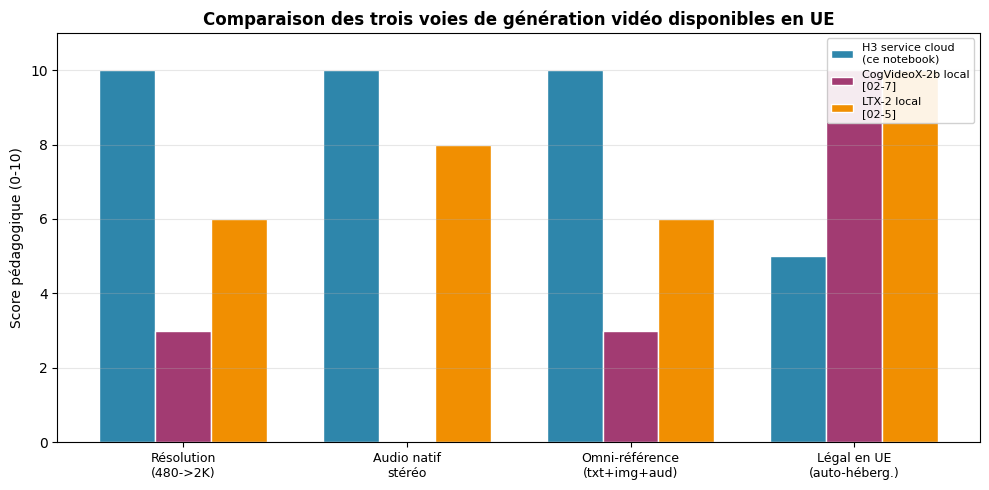

Figure : le service cloud H3 maximise résolution/audio/omni-référence ; le score 'Légal UE auto-héberg.' est abaissé car les poids ne peuvent pas être hébergés localement.


In [5]:
# Visualisation comparative : ce que chaque voie (UE-légale) offre
# Chart 100% déterministe — aucune clé, aucun réseau requis.
labels = ["H3 service cloud\n(ce notebook)", "CogVideoX-2b local\n[02-7]", "LTX-2 local\n[02-5]"]
# Scores normalisés 0-10 sur 4 axes (approx. pédagogique)
axes_names = ["Résolution\n(480->2K)", "Audio natif\nstéréo", "Omni-référence\n(txt+img+aud)", "Légal en UE\n(auto-héberg.)"]
scores = {
    "H3 service cloud\n(ce notebook)": [10, 10, 10, 5],   # auto-héberg. interdit, service OK
    "CogVideoX-2b local\n[02-7]":       [3, 0, 3, 10],   # 480p, muet, Apache-2.0
    "LTX-2 local\n[02-5]":              [6, 8, 6, 10],   # 768p, audio, UE-permissive
}
colors = ["#2E86AB", "#A23B72", "#F18F01"]

import numpy as np
x = np.arange(len(axes_names))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
for i, (lab, vals) in enumerate(scores.items()):
    ax.bar(x + (i - 1) * width, vals, width, label=lab, color=colors[i], edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(axes_names, fontsize=9)
ax.set_ylabel("Score pédagogique (0-10)")
ax.set_ylim(0, 11)
ax.set_title("Comparaison des trois voies de génération vidéo disponibles en UE", fontweight="bold")
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plt.show()
print("Figure : le service cloud H3 maximise résolution/audio/omni-référence ; "
      "le score 'Légal UE auto-héberg.' est abaissé car les poids ne peuvent pas être hébergés localement.")

### Interprétation — Bifurcation licence-poids vs ToS-service

**Sortie obtenue** : tableau de statut (2 scénarios omni-modaux) + comparatif visuel des trois voies UE-légales.

| Voie | Résolution | Audio natif | Licence/ToS en UE | Verdict |
|------|-----------|-------------|-------------------|---------|
| **H3 service cloud** (04-5) | HD / 2K | Stéréo synchronisé | ToS service : OK | **SOTA-OK** (cloud) |
| CogVideoX-2b local (02-7) | 480p | Muet | Apache-2.0 : OK | Local dégradé mais libre |
| LTX-2 local (02-5) | 768p | Oui | UE-permissive : OK | Local audiovisuel |
| H3 *poids* auto-hébergés | — | — | Community License : **UE exclue** | **INTRINSIC** (interdit) |

**Points clés** :

1. Le service cloud est l'**unique voie légale en UE** pour la pleine capacité H3 (HD/2K + audio stéréo + omni-référence).
2. L'idempotence (`MINIMAX_SPEND_QUOTA`) protège le quota quotidien de 5 générations — une ré-exécution sans artefact ne déclenche aucun appel réseau.
3. Les artefacts commités (PNG + JSON `task_id`) suffisent comme **preuve d'exécution** ; les `.mp4` HD restent sur GDrive privé.

> **Note technique** : le `task_id` dans `response.json` est la preuve cryptographique d'exécution côté service. Il est repris dans les exercices ci-dessous.

## Section 2 — Exercices

### Exercice 1 — Parser une réponse JSON Hailuo (extraire task_id + statut)

**Objectif** : implémenter une fonction qui parse le `response.json` d'un scénario et en extrait les champs de preuve (`task_id`, `model`, `prompt`, `resolution`, `duration`, `date UTC`, `status`).

**Contexte** : le fichier `response.json` est la preuve d'exécution d'une génération cloud. En extraire proprement les métadonnées permet de vérifier qu'une génération a bien eu lieu (sans avoir à recharger la vidéo HD).

**Indices** :
- `# Étape 1` : ouvrir le JSON depuis `ARTIFACTS_PATH / name / "response.json"`.
- `# Étape 2` : extraire les 7 champs ci-dessus avec `.get()` (valeurs absentes -> `None`).
- `# Étape 3` : retourner un dictionnaire typé ; retour `None` si le fichier est absent.

In [6]:
def parse_hailuo_response(name: str) -> dict:
    """Extrait les champs de preuve du response.json d'un scénario Hailuo.

    Args:
        name: nom du scénario (clé de SCENARIOS).

    Returns:
        Dictionnaire {task_id, model, prompt, resolution, duration, date_utc, status},
        ou None si l'artefact est absent.
    """
    # TODO étudiant : parser ARTIFACTS_PATH / name / "response.json"
    result = None  # TODO étudiant : remplir avec les champs extraits
    return result


print("Exercice 1 — parser response.json :", parse_hailuo_response("image_plus_prompt_orchestre"))

Exercice 1 — parser response.json : None


### Exercice 2 — Statistiques de forme d'onde audio (depuis un artefact)

**Objectif** : calculer des statistiques (RMS, crêtes, dynamique) sur la forme d'onde audio PNG extraite d'un scénario, afin de quantifier la **présence audio native** (la capacité distinctive du service cloud).

**Contexte** : `waveform.png` est l'image extraite via `ffmpeg` de la piste audio stéréo de la génération H3. Mesurer son amplitude renseigne sur le fait que l'audio est bien non-trivial (et non un silence plat) — ce qui est précisément ce que le local CogVideoX (02-7) ne peut pas produire.

**Indices** :
- `# Étape 1` : charger `waveform.png` avec `PIL.Image.open(...).convert("L")`.
- `# Étape 2` : convertir en tableau numpy ; l'amplitude ~ écart à 128 (niveau de gris moyen).
- `# Étape 3` : calculer RMS, max, min, dynamique (max-min) ; retourner un dict ou None si absent.

In [7]:
def audio_waveform_stats(name: str) -> dict:
    """Calcule des statistiques d'amplitude sur la waveform PNG d'un scénario.

    Returns:
        {"rms": float, "peak": float, "dynamic_range": float} ou None si absent.
    """
    # TODO étudiant : charger waveform.png et calculer les stats
    result = None  # TODO étudiant : remplir
    return result


print("Exercice 2 — stats waveform :", audio_waveform_stats("text_only_ambiance_sonore"))

Exercice 2 — stats waveform : None


### Exercice 3 — Tableau comparatif coût/qualité (cloud-H3 vs local-CogVideoX vs local-LTX-2)

**Objectif** : construire un tableau de comparaison synthétique (résolution, audio natif, licence UE, coût/génération, latence, reversibilité) pour les trois voies UE-légales, afin de décider quelle voie utiliser selon le cas d'usage.

**Contexte** : la décision cloud-vs-local dépend du volume, de la confidentialité et de la réversibilité. Ce tableau est la synthèse opérationnelle du verdict SOTA de [02-6](../02-Advanced/02-6-MiniMax-H3-Architecture-Licensing.ipynb).

**Indices** :
- `# Étape 1` : définir une liste de dictionnaires (un par voie) avec les 6 champs.
- `# Étape 2` : les coûts H3 cloud viennent de la grille MiniMax Open Platform (~$0.5-1/génération 2K).
- `# Étape 3` : indiquer la **reversibilité** (le cloud n'est pas réversible ; les poids CogVideoX/LTX-2 le sont). Retourner la liste, ou None.

In [8]:
def build_comparison_table() -> list:
    """Construit le tableau comparatif des trois voies de génération vidéo en UE.

    Returns:
        Liste de dicts {voie, resolution, audio_natif, licence_ue, cout_gen, latence, reversibilite},
        ou None (stub).
    """
    # TODO étudiant : remplir les 3 voies (H3 cloud, CogVideoX-2b local, LTX-2 local)
    table = None  # TODO étudiant : remplir
    return table


print("Exercice 3 — tableau comparatif :", build_comparison_table())

Exercice 3 — tableau comparatif : None


## Section 3 — Conclusion

### Verdict SOTA consolidé

| Notebook | Voie | Verdict | Ce qu'elle offre en UE |
|----------|------|---------|------------------------|
| [02-6](../02-Advanced/02-6-MiniMax-H3-Architecture-Licensing.ipynb) | H3 *poids* auto-hébergés | **INTRINSIC** | Rien (UE exclue par la Community License) |
| [02-7](../02-Advanced/) | CogVideoX-2b local | Local libre | 480p, muet, Apache-2.0 |
| **04-5 (ce notebook)** | **H3 service cloud** | **SOTA-OK (cloud)** | **HD/2K + audio stéréo + omni-référence** |

### Réversibilité et souveraineté

- Le **service cloud n'est pas réversible** : les sorties dépendent de la disponibilité du service Hailuo et de la grille tarifaire de MiniMax Open Platform. Pour un besoin souverain, CogVideoX-2b (Apache-2.0) et LTX-2 (UE-permissive) restent les options locales.
- Le **compromis** : le cloud achète la qualité maximale (HD/2K + audio natif) au prix de la dépendance ; le local achète la souveraineté au prix d'une qualité moindre. C'est un choix **délibéré**, documenté en 02-6.

### Points à retenir

1. **Bifurcation juridique** : licence des poids (UE exclue, INTRINSIC) ≠ ToS du service (UE ouverte, SOTA-OK).
2. **Idempotence** : `MINIMAX_SPEND_QUOTA=0` protège le quota de 5 générations/jour ; les artefacts commités (PNG + JSON `task_id`) sont la preuve d'exécution.
3. **Capacité distinctive** : HD/2K + audio stéréo natif synchronisé + entrées omni-références — exercée ici par 2 scénarios omni-modaux, pas 5 t2v triviaux.
4. **Aucun `.mp4` commité** : les originaux HD vont sur GDrive privé ; le dépôt ne garde que les preuves légères.

> **Pour aller plus loin** : combiner ce notebook avec [02-5 (LTX-2)](../02-Advanced/02-5-LTX2-Audiovisual.ipynb) pour un pipeline hybride cloud-souverain (H3 cloud pour la qualité, LTX-2 local pour la réversibilité).

---

**Navigation** : [<< 04-3 Sora API Cloud Video](04-3-Sora-API-Cloud-Video.ipynb) | [↑ Video Applications](README.md) | [↑ Video Series](../README.md)

*MiniMax H3 (Hailuo) — Génération vidéo par le service cloud · Module 04-Applications · voie cloud OUVERTE en UE (ToS service), auto-hébergement INTRINSIC (Community License).*